<a href="https://colab.research.google.com/github/crossbone72/AI-Class/blob/main/weak12/RNN_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv')
data = df['Close'].values.reshape(-1,1)

In [ ]:
def make_sample(data, window):
  train = []
  target = []
  for i in range(len(data)-window):
    train.append(data[i:i+window])
    target.append(data[i+window])
  return np.array(train), np.array(target)

In [ ]:
seq_data = []
for i in np.arange(0, 1000):
  seq_data += [[np.sin(np.pi * i* 0.01)]]
X, y = make_sample(seq_data, 10)

In [ ]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense

model = Sequential()
model.add(SimpleRNN(10, activation='tanh', input_shape=(10,1)))
model.add(Dense(1, activation='tanh'))
model.compile(optimizer='adam', loss='mse')

Epoch 1/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.9918e-05
Epoch 2/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.0700e-05
Epoch 3/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 6.2357e-05
Epoch 4/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.7368e-05
Epoch 5/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.3071e-05
Epoch 6/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.1596e-05
Epoch 7/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.6001e-05
Epoch 8/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 5.0696e-05
Epoch 9/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.1869e-05
Epoch 10/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.2747e-05
Epoch 11/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.1487e-05
Epoch 12/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.2846e-04
Epoch 13/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 5.0549e-05
Epoch 14/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss

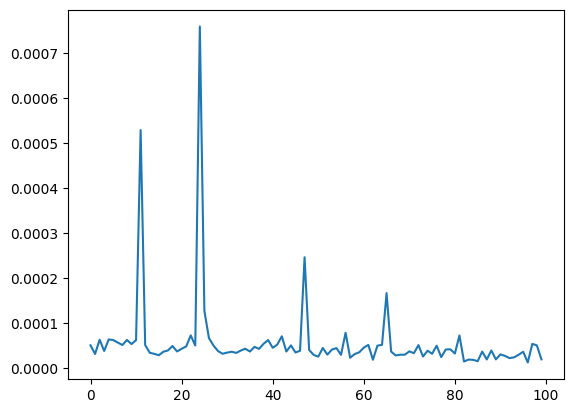

In [ ]:
history = model.fit(X, y, epochs=100, batch_size=1)
plt.plot(history.history['loss'])
plt.show()

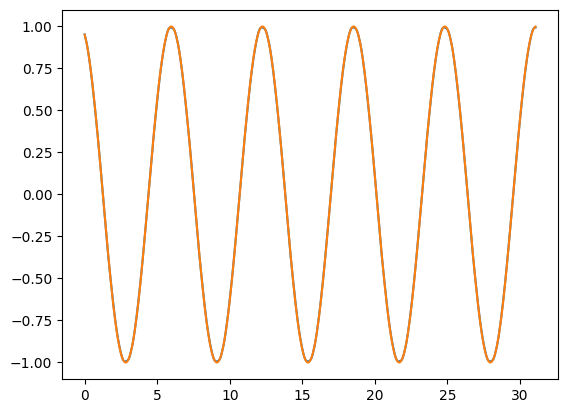

In [ ]:
seq_data = []
for i in np.arange(0, 1000):
  seq_data += [[np.cos( np.pi * i* 0.01)]]
X, y = make_sample(seq_data, 10)

y_pred = model.predict(X, verbose=0)
plt.plot(np.pi * np.arange(0, 990)*0.01, y_pred )
plt.plot(np.pi * np.arange(0, 990)*0.01, y)
plt.show()

In [ ]:
openValues = df[['Open']]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
openValues = scaler.fit_transform(openValues)

In [ ]:
TEST_SIZE = 2400
train_data = openValues[:-TEST_SIZE]
test_data = openValues[-TEST_SIZE:]

In [ ]:
def make_sample(data, window):
  train = []
  target = []
  for i in range(len(data)-window):
    train.append(data[i:i+window])
    target.append(data[i+window])
  return np.array(train), np.array(target)

X_train, y_train = make_sample(train_data, 30)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Input

model = Sequential()
model.add(Input(shape=(30, 1)))
model.add(SimpleRNN(16,
                    activation='tanh',
                    return_sequences=False))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=16)

Epoch 1/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0013
Epoch 2/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.4889e-04
Epoch 3/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1582e-04
Epoch 4/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.8720e-05
Epoch 5/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.4062e-05
Epoch 6/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.2083e-05
Epoch 7/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.5382e-05
Epoch 8/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9669e-05
Epoch 9/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.8269e-05
Epoch 10/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2354e-05
Epoch 11/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9758e-05
Epoch 12/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.9150e-05
Epoch 13/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.2973e-05
Epoch 14/100
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 5.

In [ ]:
X_test, y_test = make_sample(test_data, 10)
pred = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


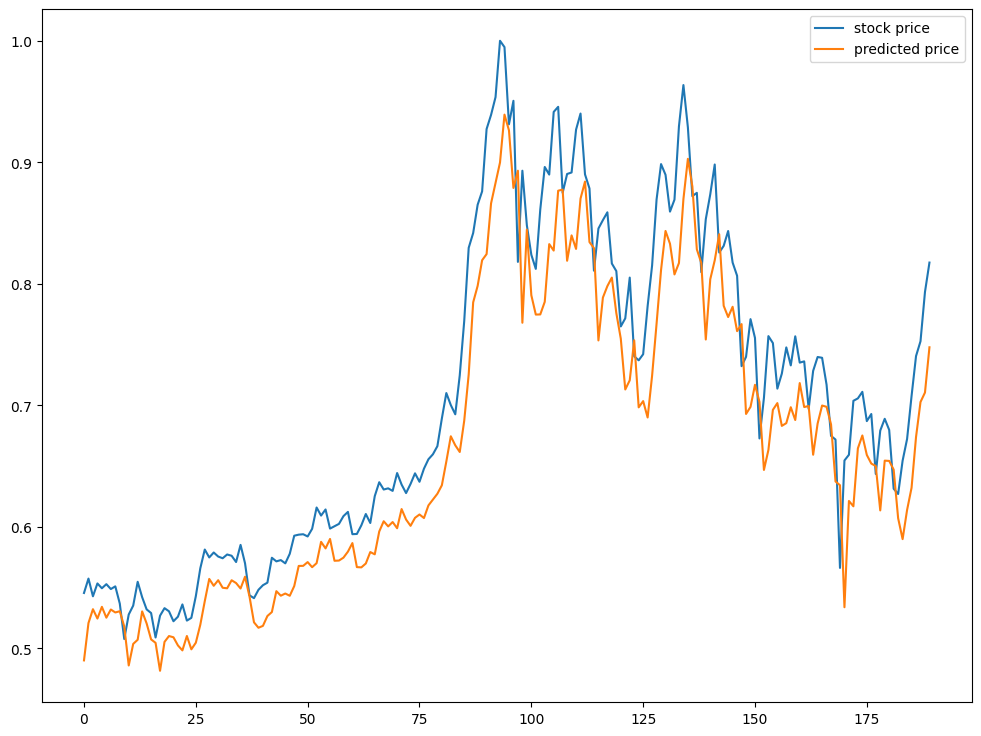

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 9))
plt.plot(y_test,label='stock price')
plt.plot(pred, label='predicted price')
plt.legend()
plt.show()